# Session 2: pandas and plotting

---
# Part 1: pandas

NumPy arrays hold numbers of one type. Real datasets are **tables**: named columns of different types, sometimes with missing values. **pandas** is the library for tables, and its `DataFrame` is what every dataset in this course is loaded into.

Today we meet three of the course datasets: bike rentals, spam emails and Swiss weather.

In [1]:
import numpy as np
import pandas as pd

DATA = "../data/" 

## 1.1 DataFrame and Series

A **DataFrame** is a table. Each column is a **Series**: a NumPy array with a name and an index. The easiest way to build a small DataFrame is from a dictionary: keys become column names.

![image.png](https://raw.githubusercontent.com/t-hossein/hands-on-ml-biotech/main/02_ObjectsAndData/images/02_Pandas_cell2_image.png)

*from https://www.geeksforgeeks.org/pandas/python-pandas-dataframe/*

In [2]:
genes = pd.DataFrame({
    "gene": ["TP53", "BRCA1", "MYC", "GAPDH", "EGFR"],
    "protein_length": [393, 1863, 439, 335, 1210],
    "chromosome": [17, 17, 8, 12, 7],
    "oncogene": [False, False, True, False, True],
})
genes

,gene,protein_length,chromosome,oncogene
0,TP53,393,17,False
1,BRCA1,1863,17,False
2,MYC,439,8,True
3,GAPDH,335,12,False
4,EGFR,1210,7,True


In [ ]:
# shape, columns and turning them to lists
print(genes.shape) # (rows, columns), like NumPy
print(genes.columns)
print(genes.columns.tolist())

(5, 4)
Index(['gene', 'protein_length', 'chromosome', 'oncogene'], dtype='str')
['gene', 'protein_length', 'chromosome', 'oncogene']


In [ ]:
# Series and their methods, getting np arrays
lengths = genes["protein_length"] # one column is a Series
print(type(lengths))
print(lengths.mean(), lengths.max())       # Numpy style methods
print(lengths.to_numpy()) # the underlying Numpy array

<class 'pandas.Series'>
848.0 1863
[ 393 1863  439  335 1210]


### ✏️ Exercise 1, part 1

Create an artificial data set `data` with three columns named A, B and C:

- **A**: 10 random numbers from a Bernoulli distribution with rate 0.3
- **B**: 10 random numbers from the uniform distribution over [0, 1)
- **C**: 10 samples from the set ("hip", "hop"), with equal probability

*Hint:* use `rng.binomial`, `rng.random` and `rng.choice` from last session.

In [5]:
rng = np.random.default_rng(0)
data = pd.DataFrame({
    "A": rng.binomial(1, 0.3, size=10),
    "B": rng.random(10),
    "C": rng.choice(["hip", "hop"], size=10),
})
data

,A,B,C
0,0,0.815854,hip
1,0,0.002739,hip
2,0,0.857404,hip
3,0,0.033586,hip
4,1,0.729655,hip
5,1,0.175656,hop
6,0,0.863179,hop
7,1,0.541461,hop
8,0,0.299712,hip
9,1,0.422687,hop


## 1.2 First look at a real dataset

`pd.read_csv` loads a CSV file into a DataFrame. Our first dataset: the number of bicycles rented in Washington D.C. in every hour of 2011 and 2012, with the weather at that time.

Whenever you load data, look at it before doing anything else.

In [6]:
bikes = pd.read_csv(DATA + "bikes.csv")
bikes.head() 

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


In [7]:
print(bikes.shape)      
bikes.dtypes # the type of each column

(17379, 13)


season            str
year            int64
month           int64
hour            int64
holiday          bool
weekday         int64
workingday       bool
weather           str
temp          float64
feel_temp     float64
humidity      float64
windspeed     float64
count           int64
dtype: object

In [8]:
bikes.describe() # summary statistics

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.502561,6.537775,11.546752,3.003683,20.376474,23.788755,0.627229,12.736540,189.463088
std,0.500008,3.438776,6.914405,2.005771,7.894801,8.592511,0.192930,8.196795,181.387599
min,0.000000,1.000000,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.000000,6.000000,1.000000,13.940000,16.665000,0.480000,7.001500,40.000000
50%,1.000000,7.000000,12.000000,3.000000,20.500000,24.240000,0.630000,12.998000,142.000000
75%,1.000000,10.000000,18.000000,5.000000,27.060000,31.060000,0.780000,16.997900,281.000000
max,1.000000,12.000000,23.000000,6.000000,41.000000,50.000000,1.000000,56.996900,977.000000


In [9]:
bikes["weather"].value_counts() 

weather
clear         11413
misty          4544
rain           1419
heavy_rain        3
Name: count, dtype: int64

Already we learn things: the columns have mixed types, `count` goes from 1 to almost 1000, and `heavy_rain` appears only 3 times in two years.

## 1.3 Missing values

Real data has holes. pandas marks a missing value as `NaN`. The second dataset: 11,512 emails labelled spam or ham (not spam).

In [10]:
spam = pd.read_csv(DATA + "spam.csv")
print(spam.shape)
spam.head()

(11512, 2)


,label,text
0,ham,start date hourahead hour start date hourahead...
1,spam,re swollen ear i final a mor t gag e l o an th...
2,ham,re ena associ analyst kitchen louis cc hilli k...
3,spam,get it up again hello tri this revolutionari p...
4,ham,hi hello there mister bill just a quick note t...


In [11]:
# count spam values
spam["label"].value_counts()

label
spam    6000
ham     5512
Name: count, dtype: int64

In [12]:
# count NaN values
spam.isna().sum()

label     0
text     35
dtype: int64

35 emails have no text. Two common ways to deal with it (we will learn more in the future. this is called data imputation):

- Dropping the `NaN` values
- Filling them with a default value

In [ ]:
spam_clean = spam.dropna() # 1. drop the rows with a missing value
spam_filled = spam.fillna({"text": ""}) # 2. fill in a default value

print(len(spam), "->", len(spam_clean), "rows after dropna")
print(spam_filled.isna().sum().sum(), "missing values after fillna")

spam = spam_clean 

11512 -> 11477 rows after dropna
0 missing values after fillna


Make `df.isna().sum()` part of your first look at every dataset. Many models refuse to run when the data contains `NaN`.


## 1.4 Selecting data

**Columns** by name:

In [14]:
print(bikes["count"].head(3)) # one column: a Series

0    16
1    40
2    32
Name: count, dtype: int64


In [15]:
bikes[["hour", "temp", "count"]].head(3) # a list of columns: a DataFrame

,hour,temp,count
0,0,9.84,16
1,1,9.02,40
2,2,9.02,32


**Rows** by position with `iloc`, or by label with `loc`. Both use `[rows, columns]`, like NumPy.

In [16]:
print(bikes.iloc[0]) 


season        spring
year               0
month              1
hour               0
holiday        False
weekday            6
workingday     False
weather        clear
temp            9.84
feel_temp     14.395
humidity        0.81
windspeed        0.0
count             16
Name: 0, dtype: object


In [17]:
bikes.iloc[:3, :4]

,season,year,month,hour
0,spring,0,1,0
1,spring,0,1,1
2,spring,0,1,2


In [18]:
bikes.loc[:3, ["hour", "weather", "count"]] # by label. Careful: loc INCLUDES the end of a slice

,hour,weather,count
0,0,clear,16
1,1,clear,40
2,2,clear,32
3,3,clear,13


**Rows by condition**: a Boolean mask, exactly as in NumPy. Combine conditions with `&` and `|`, and put each one in parentheses.

In [ ]:
is_rush_hour = bikes["hour"] == 8
is_rush_hour.head(10) # a Series of True/False, one per row

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8     True
9    False
Name: hour, dtype: bool

In [20]:
# boolean masking
bikes[is_rush_hour].head(3)                   # keeps only the rows where the mask is True

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
8,spring,0,1,8,False,6,False,clear,9.84,14.395,0.75,0.0000,8
31,spring,0,1,8,False,0,False,rain,16.40,20.455,0.71,15.0013,8
53,spring,0,1,8,False,1,True,clear,5.74,6.060,0.50,19.0012,154


In [21]:
# 8 o'clock on working days with clear weather
mask = (bikes["hour"] == 8) & bikes["workingday"] & (bikes["weather"] == "clear")
print(mask.sum(), "hours match")
print("mean rentals:", bikes.loc[mask, "count"].mean().round(1))

280 hours match
mean rentals: 503.9


### ✏️ Exercise 1, parts 2 and 3 

Using your `data` from part 1:

2. Create a vector `v` whose i-th element is the sum of the i-th entries of columns A and B.
3. Select all rows with "hop" in column C and store them in `hop_rows`.

In [22]:
v = (data["A"] + data["B"]).to_numpy()
hop_rows = data[data["C"] == "hop"]
print(v.round(2))
hop_rows

[0.82 0.   0.86 0.03 1.73 1.18 0.86 1.54 0.3  1.42]


,A,B,C
5,1,0.175656,hop
6,0,0.863179,hop
7,1,0.541461,hop
9,1,0.422687,hop


### ✏️ In how many hours were **more than 800** bicycles rented? Store the number in `n_busy`.

In [23]:
n_busy = (bikes["count"] > 800).sum()
n_busy

np.int64(147)


## 1.5 New columns

Assigning to a column name that doesn't exist creates the column. Operations on columns are vectorised, like NumPy.

In [24]:
bikes["temp_fahrenheit"] = bikes["temp"] * 9 / 5 + 32
bikes[["temp", "temp_fahrenheit"]].head(3)

,temp,temp_fahrenheit
0,9.84,49.712
1,9.02,48.236
2,9.02,48.236


Text columns have string methods under `.str`:

In [25]:
spam["length"] = spam["text"].str.len() 
spam["has_free"] = spam["text"].str.contains("free")     # does the word appear?
spam.head()

,label,text,length,has_free
0,ham,start date hourahead hour start date hourahead...,311,False
1,spam,re swollen ear i final a mor t gag e l o an th...,2469,False
2,ham,re ena associ analyst kitchen louis cc hilli k...,120,False
3,spam,get it up again hello tri this revolutionari p...,807,False
4,ham,hi hello there mister bill just a quick note t...,947,False


`apply` runs your own function on every value. This is where `lambda` from last session is handy. It is slower than a vectorised operation, so use it only when there is no built-in way.

In [26]:
spam["n_words"] = spam["text"].apply(lambda text: len(text.split()))
spam[["label", "length", "n_words"]].head()

,label,length,n_words
0,ham,311,53
1,spam,2469,332
2,ham,120,20
3,spam,807,155
4,ham,947,216


The third dataset: hourly weather measurements from stations all over Switzerland.

In [27]:
weather = pd.read_csv(DATA + "weather.csv")
print(weather.shape)
weather.iloc[:3, :5]

(25218, 57)


,time,BAS_wind_peak,BAS_pressure,BAS_temperature,BAS_precipitation
0,2015010100,8.6,997.1,-5.2,0.0
1,2015010101,6.5,997.3,-6.1,0.0
2,2015010102,5.0,997.6,-5.6,0.0


### 1.6 Grouping

`groupby` splits the rows into groups, computes something for each group, and puts the results together. Read it as a sentence: *group the bikes by hour, take the count column, compute the mean.*

In [28]:
bikes.groupby("hour")[["count"]].mean().round(1)

,count
hour,
0,53.9
1,33.4
2,22.9
3,11.7
4,6.4
5,19.9
6,76.0
7,212.1
8,359.0


In [29]:
# show "length", "n_words", "has_free", grouped by labels
spam.groupby("label")[["length", "n_words", "has_free"]].mean().round(2)

,length,n_words,has_free
label,,,
ham,1926.61,364.70,0.07
spam,1014.56,185.67,0.17


Spam emails in this dataset are shorter on average, and mention "free" more often. Simple numbers like these can become **features** for a model.

### ✏️ Compute the mean number of rentals for each season and store the result in `season_means`. Which season is the busiest?

In [30]:
season_means = bikes.groupby("season")["count"].mean()
print("busiest:", season_means.idxmax())
season_means.round(1)

busiest: fall


season
fall      236.0
spring    111.1
summer    208.3
winter    198.9
Name: count, dtype: float64

## 1.7 Reading and writing CSV files

### ✏️ Exercise 2, part 4

The Iris dataset is in the data folder as `iris.csv`.

1. Load it into a DataFrame called `iris`.
2. Write it to a new file `iris_copy.csv` with `to_csv`. Use `index=False` so the row numbers are not saved as an extra column.
3. Read `iris_copy.csv` back into a DataFrame called `iris_saved`.

In [31]:
iris = pd.read_csv(DATA + "iris.csv")
iris.to_csv("iris_copy.csv", index=False)
iris_saved = pd.read_csv("iris_copy.csv")
iris_saved

,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


---
# Part 2: Plotting

**Always look at your data before fitting a model.** A plot shows in a second what a table of numbers hides: outliers, long tails, groups, trends.

We use two libraries:

- **matplotlib** draws anything, one element at a time.
- **seaborn** is built on top of it and draws common statistical plots straight from a DataFrame.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA = "../data/" # Or, alternatively, you can use "https://raw.githubusercontent.com/t-hossein/hands-on-ml-biotech/main/data/"


weather = pd.read_csv(DATA + "weather.csv")
weather["time"] = pd.to_datetime(weather["time"].astype(str), format="%Y%m%d%H")
weather["LUZ_wind_peak_in5h"] = weather["LUZ_wind_peak"].shift(-5)

bikes = pd.read_csv(DATA + "bikes.csv")

spam = pd.read_csv(DATA + "spam.csv").dropna()
spam["length"] = spam["text"].str.len()

mnist = pd.read_csv(DATA + "mnist_small.csv")
iris = pd.read_csv(DATA + "iris.csv")

print("weather", weather.shape,
      "\nbikes", bikes.shape, 
      "\nspam", spam.shape, 
      "\nmnist", mnist.shape, 
      "\niris", iris.shape)

weather (25218, 58) 
bikes (17379, 13) 
spam (11477, 3) 
mnist (1000, 785) 
iris (150, 5)


---
## 2.1 The anatomy of a plot

`plt.subplots()` gives you two objects:

- the **figure**: the whole image
- the **axes**: one plot inside it, with its x and y axis

You draw by calling methods on the axes. **A plot without axis labels is not finished.**

First plot: the wind peak in Luzern during the first week of 2015.

In [2]:
week = weather.iloc[:7 * 24] # 7 days

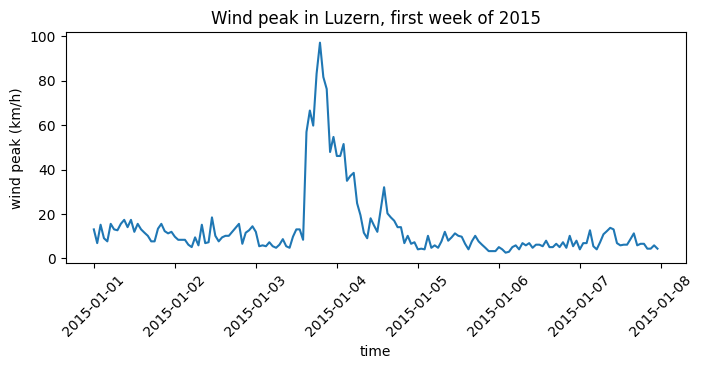

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(week["time"], week["LUZ_wind_peak"])
ax.set_xlabel("time")
ax.set_ylabel("wind peak (km/h)")
ax.set_title("Wind peak in Luzern, first week of 2015")
ax.tick_params(axis="x", rotation=45) # tilt the date labels so they don't overlap
plt.show()

Several lines go on the same axes. Give each a `label` and call `ax.legend()`.

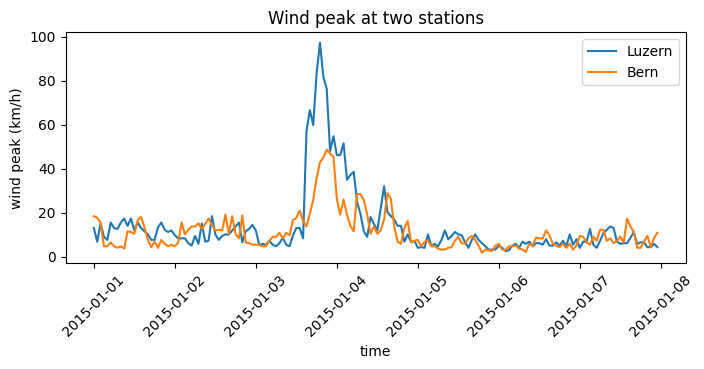

In [7]:
# "Luzern" and "Bern"
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(week["time"], week["LUZ_wind_peak"], label="Luzern")
ax.plot(week["time"], week["BER_wind_peak"], label="Bern")
ax.set_xlabel("time")
ax.set_ylabel("wind peak (km/h)")
ax.set_title("Wind peak at two stations")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.show()

## 2.2 Histogram: how is one variable distributed?

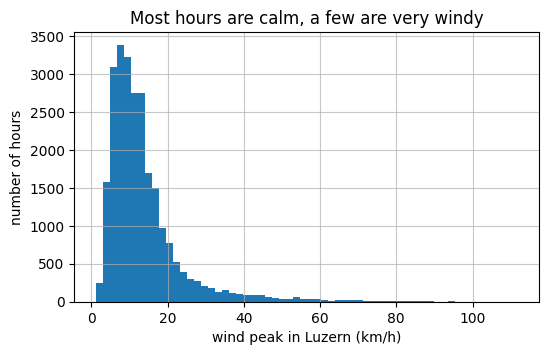

In [11]:
# set an appropriate number for bins
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(weather["LUZ_wind_peak"], bins=60) # too few bins hide the shape, too many make it noisy
ax.set_xlabel("wind peak in Luzern (km/h)")
ax.set_ylabel("number of hours")
ax.set_title("Most hours are calm, a few are very windy")
ax.grid(alpha=0.7)
plt.show()

The distribution has a **long tail** to the right: strong winds are rare. Those rare hours are exactly the ones a wind forecast should get right.

Later, we see that may have to transform *skewed* data.

## 2.3 Scatter plot: how are two variables related?

Does the air pressure in Luzern tell us something about the wind 5 hours later? With 25,000 points, use a small `alpha` (transparency) so that dense regions show up darker.

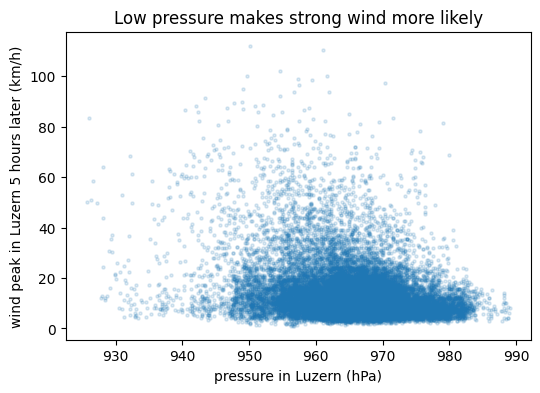

In [ ]:
# set s, c and alpha
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(weather["LUZ_pressure"], weather["LUZ_wind_peak_in5h"],
           s=5, c="tab:blue", alpha=0.15) # s: marker size, c: colour, alpha: transparency
ax.set_xlabel("pressure in Luzern (hPa)")
ax.set_ylabel("wind peak in Luzern 5 hours later (km/h)")
ax.set_title("Low pressure makes strong wind more likely")
plt.show()

Two things to see:

- The lower the pressure, the more likely a strong wind. Pressure carries **information** about the target.
- For one pressure value there are many different wind peaks. No function `wind = f(pressure)` can describe this data exactly. A model can only say what is **likely**.

## 2.4 Several plots in one figure

`plt.subplots(1, 2)` gives a row of two axes.

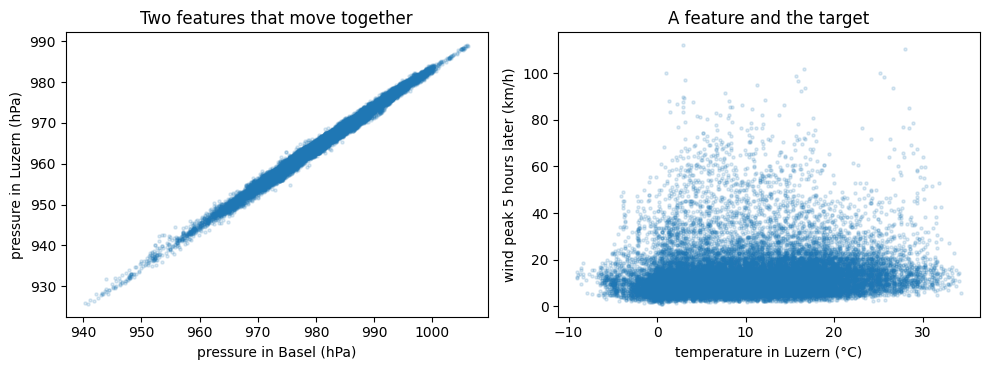

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].scatter(weather["BAS_pressure"], weather["LUZ_pressure"], s=5, alpha=0.15)
axes[0].set_xlabel("pressure in Basel (hPa)")
axes[0].set_ylabel("pressure in Luzern (hPa)")
axes[0].set_title("Two features that move together")

axes[1].scatter(weather["LUZ_temperature"], weather["LUZ_wind_peak_in5h"], s=5, alpha=0.15)
axes[1].set_xlabel("temperature in Luzern (°C)")
axes[1].set_ylabel("wind peak 5 hours later (km/h)")
axes[1].set_title("A feature and the target")

fig.tight_layout()
plt.show()

## 2.5 seaborn: plots straight from a DataFrame

With seaborn you name the DataFrame and the columns, and it does the grouping, the colours and the legend. `hue` splits the data by a column.

**Bike rentals.** When do people rent bicycles? `lineplot` computes the mean of `count` for every hour.

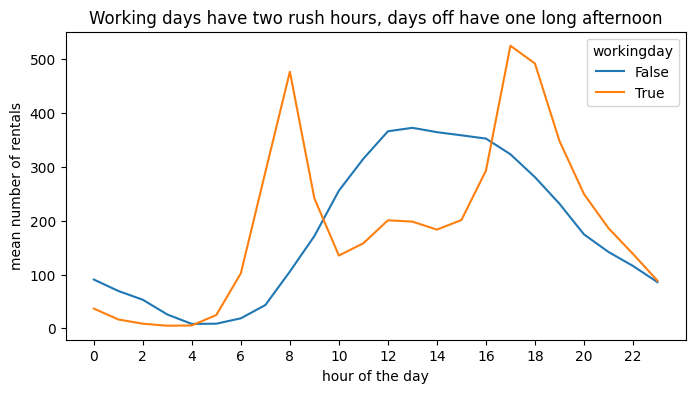

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=bikes, x="hour", y="count", hue="workingday", errorbar=None, ax=ax)
ax.set_xlabel("hour of the day")
ax.set_ylabel("mean number of rentals")
ax.set_title("Working days have two rush hours, days off have one long afternoon")
ax.set_xticks(range(0, 24, 2))
plt.show()

One plot, and we know that `hour` matters, that `workingday` matters, and that their effect is **combined**: the hour means something different on a Sunday.

A **box plot** compares a number across categories. The box holds the middle half of the values, and the line inside it is the median.

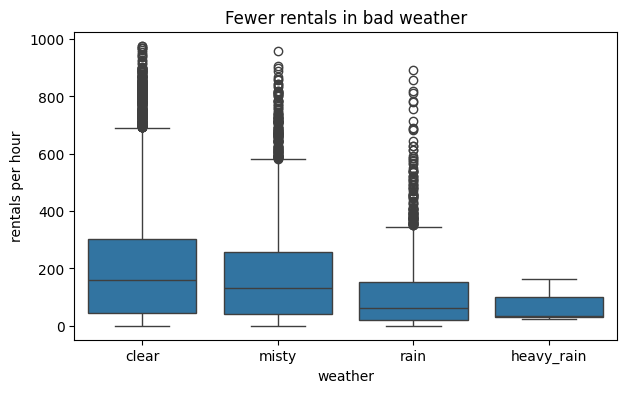

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=bikes, x="weather", y="count", order=["clear", "misty", "rain", "heavy_rain"], ax=ax)
ax.set_xlabel("weather")
ax.set_ylabel("rentals per hour")
ax.set_title("Fewer rentals in bad weather")
plt.show()

(`heavy_rain` has only 3 hours in the whole dataset, so its box means little.)

**Spam.** A count plot shows how many samples each class has. Check this for every classification dataset: if one class is rare, accuracy becomes misleading.

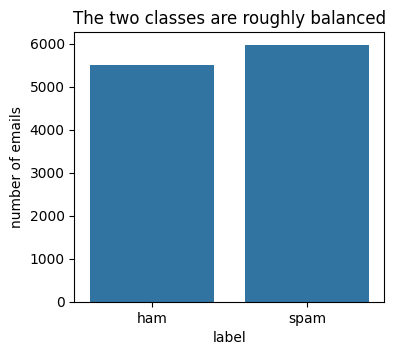

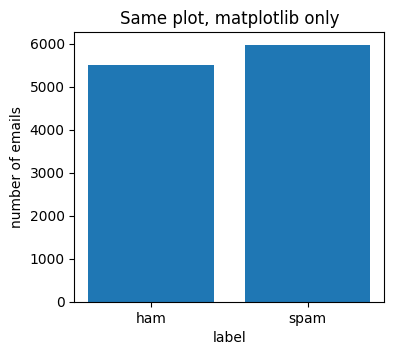

In [41]:
# also see the matplotlib method
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.countplot(data=spam, x="label", order=["ham", "spam"], ax=ax)
ax.set_xlabel("label")
ax.set_ylabel("number of emails")
ax.set_title("The two classes are roughly balanced")
plt.show()

# The same plot with matplotlib only: count first, then draw the bars yourself
counts = spam["label"].value_counts().loc[["ham", "spam"]]

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.bar(counts.index, counts.values)
ax.set_xlabel("label")
ax.set_ylabel("number of emails")
ax.set_title("Same plot, matplotlib only")
plt.show()

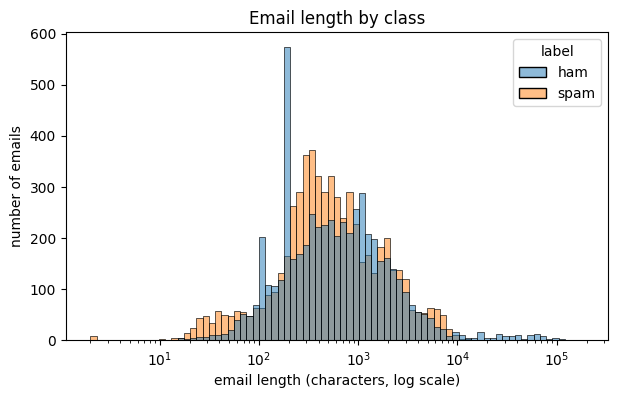

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=spam, x="length", hue="label", hue_order=["ham", "spam"], log_scale=True, ax=ax)
ax.set_xlabel("email length (characters, log scale)")
ax.set_ylabel("number of emails")
ax.set_title("Email length by class")
plt.show()

Email lengths range from a few characters to tens of thousands, so the x axis uses a **log scale**. The two classes overlap a lot: length alone will not separate spam from ham, but it is our first numerical feature made from text.

## 2.6 Images are data too

**MNIST.** Each row holds one handwritten digit as 784 pixel values, plus its label. To see it, reshape the row back to 28×28 (as in the NumPy notebook) and show it with `imshow`.

In [43]:
print(mnist.shape) 
mnist.iloc[:3, [0, 1, 300, 301, 783, 784]]

(1000, 785)


,pixel1,pixel2,pixel301,pixel302,pixel784,class
0,0,0,254,106,0,7
1,0,0,0,0,0,2
2,0,0,0,0,0,1


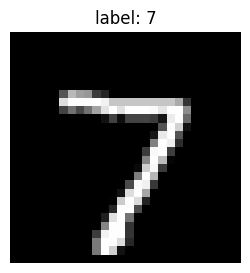

In [44]:
pixels = mnist.drop(columns="class").to_numpy()
labels = mnist["class"].to_numpy()

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(pixels[0].reshape(28, 28), cmap="gray")
ax.set_title(f"label: {labels[0]}")
ax.axis("off")
plt.show()

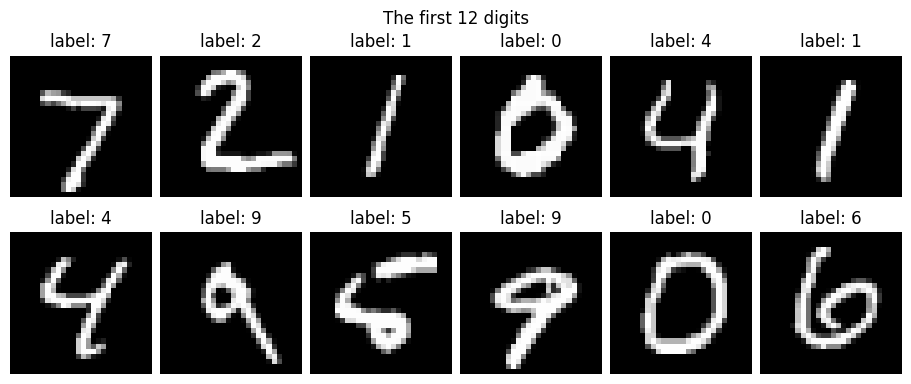

In [45]:
# A grid of axes: 2 rows, 6 columns. axes.flat walks through all of them.
fig, axes = plt.subplots(2, 6, figsize=(9, 3.8), layout="constrained")
for i, ax in enumerate(axes.flat):
    ax.imshow(pixels[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"label: {labels[i]}")
    ax.axis("off")
fig.suptitle("The first 12 digits")
plt.show()

## 2.7 Exercises

### ✏️ Exercise 2, parts 5 and 6

Using the `iris` DataFrame:

5. Produce a scatter plot of `sepal-length` versus `sepal-width`. Make sure both axes have the correct labels.
6. Add the identity line y = x to the same plot in red.

*Hint:* for the line, create x values with `np.linspace(4, 8, 100)` and plot them against themselves.

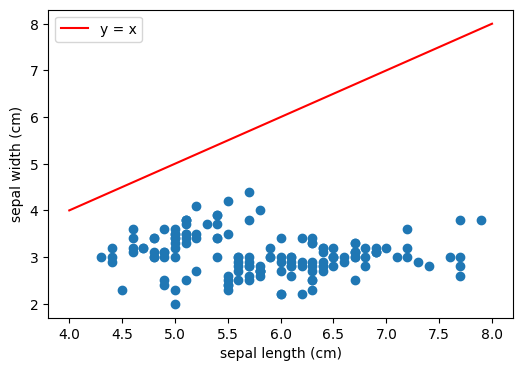

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(iris["sepallength"], iris["sepalwidth"])

x = np.linspace(4, 8, 100)
ax.plot(x, x, color="red", label="y = x")

ax.set_xlabel("sepal length (cm)")
ax.set_ylabel("sepal width (cm)")
ax.legend()
plt.show()

## 2.8 Many variables at once: the pair plot

A pair plot draws every pair of columns against each other, with a histogram of each column on the diagonal. It is a quick way to look at raw data. We take a random sample of 2000 hours to keep it fast.

In [47]:
columns = ["BAS_pressure", "LUZ_pressure", "LUZ_wind_peak_in5h"]
sample = weather[columns].dropna().sample(2000, random_state=0)

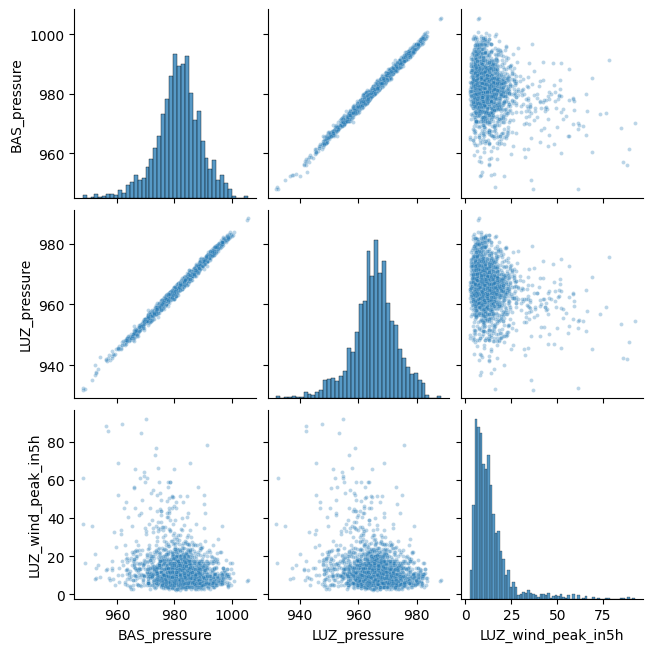

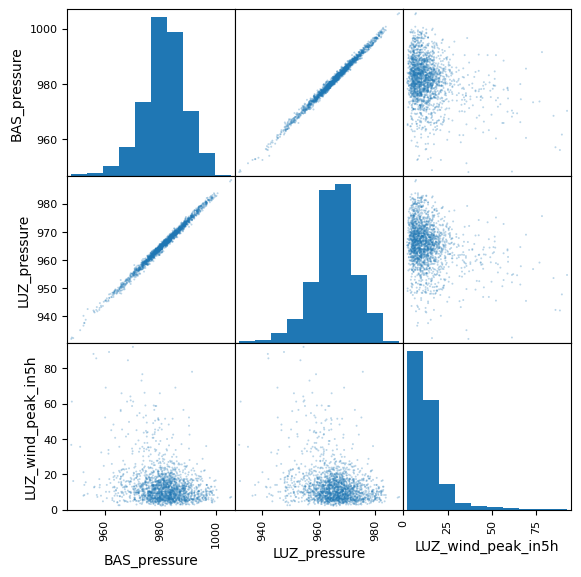

In [ ]:
# also see scatter_matrix
grid = sns.pairplot(sample, height=2.2, plot_kws={"s": 8, "alpha": 0.3})
plt.show()

# pandas has its own version, built on matplotlib
pd.plotting.scatter_matrix(sample, figsize=(6.5, 6.5), s=8, alpha=0.3)
plt.show()

What do you see?

- `LUZ_wind_peak_in5h` has a long tail.
- At low pressure there are outliers with strong wind.
- The pressure in Basel and in Luzern are highly correlated: the second one adds little new information.

## 2.9 Saving a figure

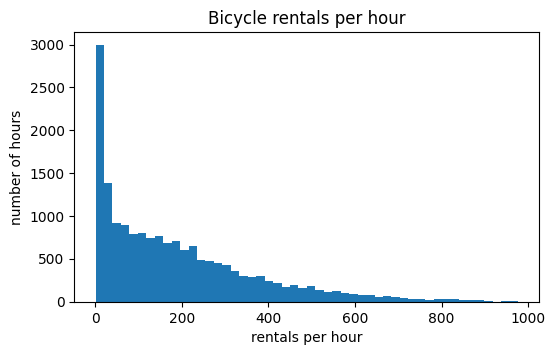

In [49]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(bikes["count"], bins=50)
ax.set_xlabel("rentals per hour")
ax.set_ylabel("number of hours")
ax.set_title("Bicycle rentals per hour")
fig.savefig("rentals_histogram.png") # save before plt.show()
plt.show()

## Homework

1. **Exercise 3** from the exercise sheet: for each scenario, decide classification or regression, inference or prediction, and give n and p.
2. **Exercise 2, parts 1 to 3**: look at the description of OpenML dataset 61, load it into a DataFrame and write it to a CSV file.
3. For each of the four datasets (MNIST, spam, weather, bike rentals), write down: what is one sample, what are the features, what is the target, and is it classification or regression?